In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import os

In [ ]:
%pip install pyspectra

  Preparing metadata (setup.py) ... done
  Created wheel for spc-spectra: filename=spc_spectra-0.4.0-py3-none-any.whl size=10341 sha256=8dc77c724c4f9d352e2f869d13118e26fe0059e3e612515404960eb3542cdb2b
  Stored in directory: /root/.cache/pip/wheels/5b/33/f9/831817af9ba4c2420157715fc532c4cc3ef550803d1a30b001
Successfully built spc-spectra


In [ ]:
from pyspectra.readers.read_spc import spc
from pyspectra.readers.read_spc import read_spc
from pyspectra.readers.read_spc import read_spc_dir

# Data representation

In [ ]:
def dissymmetry_factor(s1, s2, lamp1, lamp2):
  return 2*np.multiply(np.multiply(s1, np.reciprocal(lamp1)) - np.multiply(s2, np.reciprocal(lamp2)),
    np.reciprocal(np.multiply(s1, np.reciprocal(lamp1)) + np.multiply(s2, np.reciprocal(lamp2))))

def dissymmetry_factor_unnorm(s1, s2):
  return 2*np.multiply((s1 - s2), np.reciprocal(s1 + s2))

def adjust_lightness(color, amount):
    import matplotlib.colors as mc
    import colorsys
    try:
      c = mc.cnames[color]
    except:
      c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], max(0, min(1, amount * c[1])), c[2])

# Correlations

In [ ]:
from scipy.signal import correlate, convolve

In [ ]:
# Below we define the correlation functions:
# correlation(x,y) - unnormalized correlation function
# correlation_2(x,y) - correlation function normalized on the value of
# autocorrelations of inputs x and y

def correlation(x, y):
  result = np.correlate(x, y, mode='full')
  return result

def correlation_2(x, y):
  return np.divide(np.correlate(x, y, mode='full'), np.sqrt(np.multiply(np.correlate(x, x, mode='full'), np.correlate(y, y, mode='full'))))

In [ ]:
# Auxiliary functions to find the value in an array "nums" that is the closest
# to the set quantity "value". "position" parameter defines the value to be
# chosen among the group of closely situated points that meet the condition

def find_closest_value(nums, value, position):
    diff = np.abs(nums - np.ones_like(nums)*value)
    min_diff = min(diff)
    closest_idx = np.array(np.where(diff == min_diff)[0])
    if len(closest_idx) <= 1:
        return nums[closest_idx], closest_idx
    else:
        if position == 0:
            middle_idx = np.ceil(len(closest_idx)/2)
        elif position == 1:
            middle_idx = np.floor(len(closest_idx)/2)
        return nums[closest_idx[int(middle_idx)]], closest_idx[int(middle_idx)]

def find_closest_single_extr(nums, value):
    idx = np.array([k for k in range(len(nums))])
    before_max = np.array(np.where(idx < np.argmax(nums))[0])
    closest_left, left_idx = find_closest_value(np.array([nums[k] for k in before_max]), value, 0)
    after_max = np.array(np.where(idx >= np.argmax(nums))[0])
    closest_right, right_idx = find_closest_value(np.array([nums[k] for k in after_max]), value, 1)
    return np.vstack((np.append(closest_left, closest_right), np.append(left_idx, len(before_max)+right_idx)))

In [ ]:
# Creting a gradient filling the area under a 2d plot

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def color_grad(start_color, end_color):
    start_rgba = plt.matplotlib.colors.to_rgba(start_color, alpha=1)
    end_rgba = plt.matplotlib.colors.to_rgba(end_color, alpha=1)
    return LinearSegmentedColormap.from_list("custom", [start_rgba, end_rgba])

def gradient_fill(ax, width_line, carrier, curve1, curve2, y_value, start_color, end_color):
    cmap_left = color_grad(end_color, start_color)
    cmap_right = color_grad(start_color, end_color)
    cmap_middle = color_grad(start_color, start_color)
    norm_left = plt.Normalize(min(carrier), width_line[int(0.25*len(width_line))])
    norm_right = plt.Normalize(width_line[int(0.75*len(width_line))], max(carrier))
    norm_middle = plt.Normalize(width_line[int(0.25*len(width_line))], width_line[int(0.75*len(width_line))])

    polygons = []
    colors = []

    for i in range(len(carrier)-1):
        verts = [(carrier[i], y_value, curve1[i]), (carrier[i+1], y_value, curve1[i+1]), (carrier[i+1], y_value, curve2[i+1]), (carrier[i], y_value, curve2[i])]
        polygons.append(verts)
        mid_x = (carrier[i] + carrier[i+1])/2
        if carrier[i] <= width_line[int(0.25*len(width_line))]:
            colors.append(cmap_left(norm_left(mid_x)))
        elif carrier[i] >= width_line[int(0.75*len(width_line))]:
            colors.append(cmap_right(norm_right(mid_x)))
        else:
            colors.append(cmap_middle(norm_middle(mid_x)))

    poly = Poly3DCollection(polygons, facecolors=colors, edgecolors='none')
    poly.set_alpha(1)
    ax.add_collection3d(poly)

In [ ]:
import matplotlib.ticker as mticker
from mpl_toolkits import mplot3d

In [ ]:
# Checking the concavity of the area contour

def concave_check(input, position):
  lda = 1/2
  res_check = []
  n = 0
  for i in range(len(input)-2):
    for j in range(i+2, len(input)):
      res_check = np.append(res_check, bool(find_closest_value(input, input[i]*lda + input[j]*(1-lda), position)[0] >=
        find_closest_value(input, input[i], position)[0]*lda + find_closest_value(input, input[j], position)[0]*(1-lda)))
      n += 1
  return len(np.where(res_check == True)[0])/n

def calc_area(carrier, input):
  return np.sum(np.multiply(np.diff(carrier), input[:-1] + input[1:])/2)

def dyssim_area(carrier, before_max, after_max, input):
  reduced_area_before_max = calc_area(carrier[before_max:np.argmax(input)], input[before_max:np.argmax(input)])*concave_check(input[before_max:np.argmax(input):int(len(carrier)/200)], 0)
  reduced_area_after_max = calc_area(carrier[np.argmax(input):after_max], input[np.argmax(input):after_max])*concave_check(input[np.argmax(input):after_max:int(len(carrier)/200)], 1)
  return np.round_((reduced_area_after_max - reduced_area_before_max)/(reduced_area_after_max + reduced_area_before_max)*100, decimals=1)

In [ ]:
import matplotlib.patheffects as pe

In [ ]:
# Now we are applying an algorithm of local maxima search

from scipy.signal import find_peaks

In [ ]:
from sklearn.cluster import MeanShift, estimate_bandwidth
from scipy.signal import savgol_filter

def group_by(input, carrier, to_interp=None, poly_order=6):
  if type(to_interp) is not None:
    interp = np.array(savgol_filter(to_interp[1], int(0.1*len(to_interp[1]))+1, poly_order))
    print(interp.shape)
    print(carrier.shape)
    input_used = np.empty(len(carrier))
    for n in range(len(carrier)):
      input_used[n] = interp[np.where(to_interp[0] == carrier[n])[0]]
  else:
    input_used = input
  points = np.column_stack((input_used, carrier))
  bandwidth = None
  ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
  ms.fit(points)
  group_idx = np.array([], dtype=object)
  n_prev = ms.labels_[0]
  count = 0
  count_thru = 0
  group_idx = np.append(group_idx, np.array([count_thru]))
  for n in ms.labels_[1:]:
    count_thru += 1
    if n == n_prev:
      group_idx[count] = np.append(group_idx[count], count_thru)
    else:
      count += 1
      group_idx = np.append(group_idx, np.array([count_thru]))
      n_prev = n
  group_values = np.empty(len(group_idx))
  group_carrier = np.empty(len(group_idx))
  for m in range(len(group_idx)):
    if type(group_idx[m]) is int:
      group_carrier[m] = carrier[group_idx[m]]
      group_values[m] = input[group_idx[m]]
    else:
      group_carrier[m] = carrier[group_idx[m][np.argmax(input_used[group_idx[m]])]]
      group_values[m] = input[group_idx[m][np.argmax(input_used[group_idx[m]])]]

  return group_carrier, group_values

def check_proximity(input, carrier, prox_min, prox_max):
  idx_close = np.where((np.sqrt(np.diff(input)**2 + np.diff(carrier)**2) < prox_min*
                        np.sqrt((np.max(carrier)-np.min(carrier))**2 + (np.max(input)-np.min(input))**2)))[0]
  idx_remote = np.where((np.sqrt(np.diff(input)**2 + np.diff(carrier)**2) > prox_max*
                         np.sqrt((np.max(carrier)-np.min(carrier))**2 + (np.max(input)-np.min(input))**2)))[0]
  carrier_output = np.append(carrier[idx_close][np.in1d(input[idx_close], input[idx_close+1])],
                             carrier[np.append(idx_remote, len(idx_remote))])
  idx = np.unique(carrier_output, return_index=True)[1]
  carrier_output_unique = np.array([carrier_output[i] for i in sorted(idx)])
  idx_sort = np.argsort(carrier_output_unique)
  carrier_output_sorted = np.sort(carrier_output_unique)
  input_output_sorted = np.append(input[idx_close][np.in1d(input[idx_close], input[idx_close+1])],
                                  input[np.append(idx_remote, len(idx_remote))])[idx_sort]

  return carrier_output_sorted, input_output_sorted

def find_group_extremum(input, carrier, prox_min, prox_max):
  labels = group_by(input, carrier)
  carrier_extrema = []
  input_extrema = []

  for i in range(len(np.unique(labels))):
    cluster_labels = np.where(labels == i)[0]
    true_group_extremum = np.max(np.abs(input[cluster_labels]))
    input_extrema = np.append(input_extrema, true_group_extremum)
    true_group_extremum_idx = np.where(np.abs(input[cluster_labels]) == true_group_extremum)[0][0]
    carrier_group_extremum = carrier[cluster_labels][true_group_extremum_idx]
    carrier_extrema = np.append(carrier_extrema, carrier_group_extremum)

  return check_proximity(input_extrema, carrier_extrema, prox_min, prox_max)

In [ ]:
# Secondary function that allows for filtering of singularities via flattening
# the ends of a spectrum

def filter_ends(input, carrier, threshold):
  centered_carrier = carrier - np.ones_like(carrier)*np.mean(carrier)
  combined_carrier = [centered_carrier[np.where(centered_carrier >= 0)[0]], centered_carrier[np.where(centered_carrier < 0)[0]]]

  input_left = input[np.where(centered_carrier < 0)[0]]
  input_right = input[np.where(centered_carrier >= 0)[0]]
  combined_input = [input_right, input_left]

  corrected_input = []
  for i in range(0, 2):
    leftover_idx = np.where(combined_carrier[i][find_peaks(combined_input[i])[0]]*(-1)**i > threshold)[0]
    if bool(leftover_idx.size > 0) == True:
      abs_max = np.max(np.abs(combined_input[i]))
      if i%2 == 0:
        predictor = np.min(leftover_idx) - 1
        lim_predictor = np.max(np.where(combined_carrier[i]*(-1)**i < threshold)[0])
      else:
        predictor = np.max(leftover_idx) + 1
        lim_predictor = np.min(np.where(combined_carrier[i]*(-1)**i < threshold)[0])
      corrected_leftover = np.ones_like(combined_input[i][np.where(combined_carrier[i]*(-1)**i > threshold)[0]])*combined_input[i][lim_predictor]
      if i%2 == 0:
        corrected_side_input = np.append(combined_input[i][np.where(combined_carrier[i]*(-1)**i <= threshold)[0]], corrected_leftover)
      else:
        corrected_side_input = np.append(corrected_leftover, combined_input[i][np.where(combined_carrier[i]*(-1)**i <= threshold)[0]])
      corrected_input = np.append(corrected_side_input, corrected_input)
    else:
      corrected_input = np.append(combined_input[i], corrected_input)

  return corrected_input

In [ ]:
def const_interp_ends(input, threshold_coeff):
  differ = np.diff(input)
  for i in range(1, len(differ)-1):
    if differ[i-1]*threshold_coeff < differ[i] or differ[i+1]*threshold_coeff > differ[i]:
      input[i] = min(input[i-1], input[i+1])
      input[i-1] = input[i]
      input[i+1] = input[i]

  return input

In [ ]:
# Interpolation module

from scipy.interpolate import interp1d

def linear_interp(input, carrier, add_carrier):
  interp_func = interp1d(carrier, input, bounds_error=False, fill_value="extrapolate")
  add_input = interp_func(add_carrier)

  full_carrier = np.concatenate((carrier, add_carrier))
  full_carrier_sorted = np.sort(full_carrier)
  full_input_sorted = np.concatenate((input, add_input))[np.argsort(full_carrier)]

  return full_carrier_sorted, full_input_sorted

In [ ]:
def base_groups(input_all):
  idx = np.indices((1, len(input_all)))[1][0]
  idx_empty = np.array([k for k in range(len(input_all)) if len(input_all[k]) == 0])
  if len(idx_empty) > 0:
    idx_cut = np.delete(idx, idx_empty)
  else:
    idx_cut = idx
  idx_cut_obj = np.array([], dtype=object)
  count = 0
  for k in range(len(idx_cut)):
    if k == 0:
      idx_cut_obj = np.append(idx_cut_obj, np.array(idx_cut[k]))
    elif idx_cut[k-1] == idx_cut[k]-1:
      idx_cut_obj[count] = np.append(idx_cut_obj[count], idx_cut[k])
    else:
      count += 1
      idx_cut_obj = np.append(idx_cut_obj, np.array(idx_cut[k]))
  input_lens = np.array([len(x) for x in input_all])
  idx_min_lens = np.array([], dtype=int)
  for n in range(len(idx_cut_obj)):
    idx_min_lens = np.append(idx_min_lens, np.min(input_lens[idx_cut_obj[n]]))

  return np.array([[idx_min_lens[i], idx_cut_obj[i]] for i in range(len(idx_min_lens))], dtype=object)

def find_shortest_path(input_all):
  non_empty_levels = [level for level in input_all]
  if len(non_empty_levels) < 2:
    return np.array([])
  dist = {i: [(np.array([i]), np.array([]))] for i in range(len(non_empty_levels[0]))}
  for i in range(len(non_empty_levels) - 1):
    current_level = np.array(non_empty_levels[i], dtype=float)
    next_level = np.array(non_empty_levels[i + 1], dtype=float)
    new_dist = {j: [] for j in range(len(next_level))}
    for j in range(len(current_level)):
      if not dist[j]:
        continue
      distances = np.abs(next_level - current_level[j])
      for path, costs in dist[j]:
        min_dist = np.min(distances)
        min_indices = np.where(distances == min_dist)[0]
        for idx in min_indices:
          new_path = np.append(path, idx)
          new_costs = np.append(costs, min_dist)
          new_dist[idx].append((new_path, new_costs))
    dist = new_dist
  all_paths = []
  for val in dist.values():
    all_paths.extend(val)
  if not all_paths:
    raise ValueError("No valid path found through non-empty levels")
  optimal_idx = np.argmin([np.sum(costs) for _, costs in all_paths])
  optimal_short_path = all_paths[optimal_idx][0]
  full_path = []
  short_path_idx = 0
  for i in range(len(input_all)):
    full_path.append(optimal_short_path[short_path_idx])
    short_path_idx += 1

  return np.array(full_path, dtype=int)

def search_all_paths(input_all):
  path_base = base_groups(input_all)
  paths = np.empty(np.sum(path_base.T[0]), dtype=object)
  print(paths)
  count = 0
  for n in range(len(path_base)):
    input_current = input_all[path_base.T[1][n]]
    if type(input_current) is not np.ndarray:
      input_current = np.array([input_current])
    for m in range(path_base.T[0][n]):
      current_path = find_shortest_path(input_current)
      print(paths[count])
      if len(current_path) > 0:
        paths[count] = np.vstack((np.array(path_base.T[1][n]), np.array([input_current[i][current_path[i]] for i in range(len(input_current))])))
        input_current = np.array([np.delete(input_current[i], current_path[i]) for i in range(len(input_current))], dtype=object)
      else:
        paths[count] = np.vstack((np.array(path_base.T[1][n]), np.array([None])))
        input_current = np.array([np.delete(input_current[i], 0) for i in range(len(input_current))], dtype=object)
      count += 1

  return paths

# WORKS!!!!!!!!

In [ ]:
# Extending the code to adapt it to work with 2d matrices

def base_groups(input_all):
  idx = np.indices((1, len(input_all)))[1][0]
  idx_empty = np.array([k for k in range(len(input_all)) if len(input_all[k]) == 0])
  if len(idx_empty) > 0:
    idx_cut = np.delete(idx, idx_empty)
  else:
    idx_cut = idx
  idx_cut_obj = np.array([], dtype=object)
  count = 0
  for k in range(len(idx_cut)):
    if k == 0:
      idx_cut_obj = np.append(idx_cut_obj, np.array(idx_cut[k]))
    elif idx_cut[k-1] == idx_cut[k]-1:
      idx_cut_obj[count] = np.append(idx_cut_obj[count], idx_cut[k])
    else:
      count += 1
      idx_cut_obj = np.append(idx_cut_obj, np.array(idx_cut[k]))
  input_lens = np.array([len(x) for x in input_all])
  idx_min_lens = np.array([], dtype=int)
  for n in range(len(idx_cut_obj)):
    idx_min_lens = np.append(idx_min_lens, np.min(input_lens[idx_cut_obj[n]]))

  return np.array([[idx_min_lens[i], idx_cut_obj[i]] for i in range(len(idx_min_lens))], dtype=object)

def find_shortest_path_2d(input_all_2d):
  non_empty_levels = [level for level in input_all_2d]
  if len(non_empty_levels) < 2:
    return np.array([])
  dist = {i: [(np.array([i]), np.array([]))] for i in range(non_empty_levels[0].shape[1])}
  for i in range(len(non_empty_levels) - 1):
    current_level = np.array(non_empty_levels[i], dtype=float)
    next_level = np.array(non_empty_levels[i + 1], dtype=float)
    new_dist = {j: [] for j in range(next_level.shape[1])}
    for j in range(current_level.shape[1]):
      if not dist[j]:
        continue
      diff_levels = next_level - current_level[:, j].reshape(2, 1)
      distances = np.array([np.linalg.norm(diff_levels[:, i]) for i in range(diff_levels.shape[1])])
      for path, costs in dist[j]:
        min_dist = np.min(distances)
        min_indices = np.where(distances == min_dist)[0]
        for idx in min_indices:
          new_path = np.append(path, idx)
          new_costs = np.append(costs, min_dist)
          new_dist[idx].append((new_path, new_costs))
    dist = new_dist
  all_paths = []
  for val in dist.values():
    all_paths.extend(val)
  if not all_paths:
    raise ValueError("No valid path found through non-empty levels")
  optimal_idx = np.argmin([np.sum(costs) for _, costs in all_paths])
  optimal_short_path = all_paths[optimal_idx][0]
  full_path = []
  short_path_idx = 0
  for i in range(len(input_all_2d)):
    full_path.append(optimal_short_path[short_path_idx])
    short_path_idx += 1

  return np.array(full_path, dtype=int)

def search_all_paths_2d(carrier_all, input_all):
  input_all_2d = np.empty(len(carrier_all), dtype=object)
  for n in range(len(carrier_all)):
    input_all_2d[n] = np.vstack((carrier_all[n], input_all[n]))
  path_base = base_groups(input_all)
  paths = np.empty(np.sum(path_base.T[0]), dtype=object)
  count = 0
  for n in range(len(path_base)):
    input_current_2d = input_all_2d[path_base.T[1][n]]
    if type(input_current_2d) is not np.ndarray:
      input_current_2d = np.array([input_current_2d])
    for m in range(path_base.T[0][n]):
      current_path_2d = find_shortest_path_2d(input_current_2d)
      path_count = np.array([[], [], []])
      input_current_2d_new = np.empty(len(input_current_2d), dtype=object)
      if len(current_path_2d) > 0:
        for k in range(len(input_current_2d)):
          path_count = np.concatenate((path_count, np.vstack((np.array(path_base.T[1][n])[k], input_current_2d[k][:, current_path_2d[k]].reshape(2, 1)))), axis=1)
          input_current_2d_new[k] = np.delete(input_current_2d[k], current_path_2d[k], axis=1)
      else:
        for k in range(len(input_current_2d)):
          path_count = np.concatenate((path_count, np.vstack((np.array(path_base.T[1][n])[k], np.array([[None], [None]])))), axis=1)
          input_current_2d_new[k] = np.delete(input_current_2d[k], 0, axis=1)
      paths[count] = path_count
      input_current_2d = input_current_2d_new
      count += 1

  return paths

# Final data representation

$$N = 0.5$$

Stable

D-1

Right helix

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


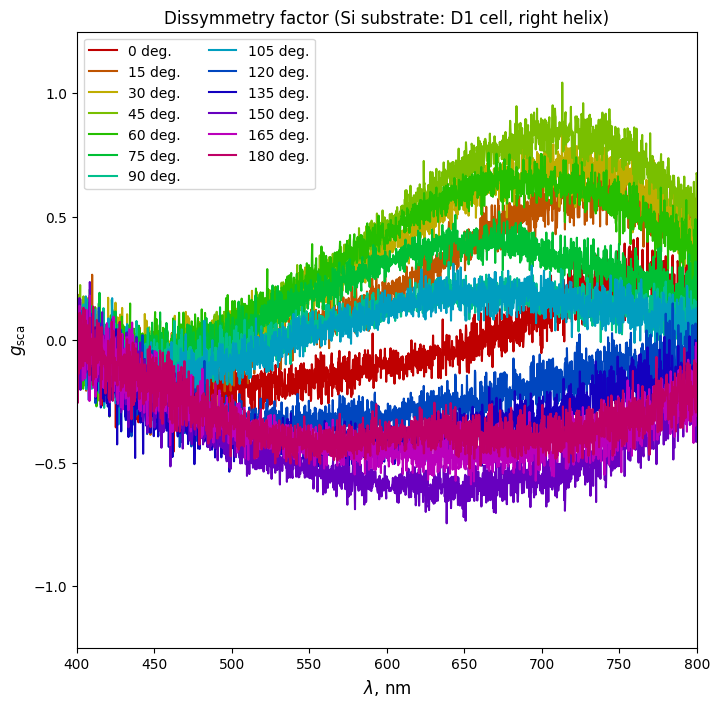

In [ ]:
lamp1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_136.spc')
lamp2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_137.spc')

r_ID = {15*i: str(32+8*i) for i in range(13)}
l_ID = {15*i: str(36+8*i) for i in range(13)}

discr_colors = cm.hsv(np.delete(np.linspace(0, 1, len(list(r_ID.keys()))+1), -1))

plt.figure(figsize=(8,8))

g_limits = np.empty_like(list(r_ID.keys()))

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(r_ID.values())[i]+'.spc')
  # print(s1.index.values)
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(l_ID.values())[i]+'.spc')
  g = dissymmetry_factor(s1, s2, lamp1, lamp2)
  g_limits[i] = max(np.abs(np.array(g)))
  plt.plot(g, color=adjust_lightness(discr_colors[i], 0.75), label='{}'.format(list(r_ID.keys())[i])+' deg.')
  plt.xlim(400, 800)

plt.ylim(-1.25*max(g_limits), 1.25*max(g_limits))
plt.xlabel(r'$\lambda$, nm', size=12)
plt.ylabel(r'$g_\text{sca}$', size=12)
plt.title(f'Dissymmetry factor (Si substrate: D1 cell, right helix)')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set3.colors)
plt.legend(ncol=2)
plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/dissym_factor_2025_04_21_D1r.png', dpi=300)

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


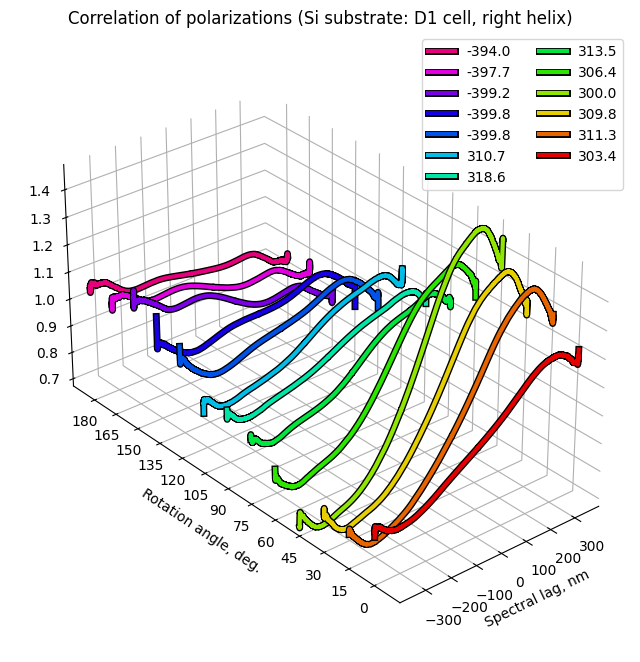

In [ ]:
fig = plt.figure(figsize=(8,9))

r_ID = {15*i: str(32+8*i) for i in range(13)}
l_ID = {15*i: str(36+8*i) for i in range(13)}

corr_limits = np.empty_like(list(r_ID.keys()))
g_limits = np.empty_like(list(r_ID.keys()))

ax = fig.add_subplot(projection='3d')
x_scaling = 2.0
y_scaling = 4.0
z_scaling = 2.0
ax.set_box_aspect([x_scaling, y_scaling, z_scaling])

shifts = []

def format_scientific(x, pos):
    return "${:.1e}$".format(x)

sci_format = mticker.FuncFormatter(format_scientific)

bottom_z_shifts = []
top_z_shifts = []

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  bottom_z_shifts = np.append(bottom_z_shifts, min(corr_g))
  top_z_shifts = np.append(top_z_shifts, max(corr_g))

bottom_z_lim = min(bottom_z_shifts)
top_z_lim = max(top_z_shifts)

for i in range(len(list(r_ID.keys()))-1, -1, -1):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  carrier_amplitude = s1.index.values[-1] - s1.index.values[0]
  corr_carrier = np.array([k for k in np.linspace(-carrier_amplitude, carrier_amplitude, len(corr_g))])
  extrema_g = find_peaks(corr_g)[0]
  corr_limits[i] = max(np.abs(np.array(corr_g)))
  shift = corr_carrier[np.argmax(corr_g)]
  ax.plot(corr_carrier, int(list(r_ID.keys())[i]), corr_g, color=adjust_lightness(discr_colors[i], 0.9), label='{}'.format(np.round(shift, decimals=1)), linewidth=3.0, path_effects=[pe.Stroke(linewidth=5.0, foreground='black'), pe.Normal()])
  shifts = np.append(shifts, shift)

ax.set_xlabel(f'Spectral lag, nm', labelpad=2)
ax.set_ylabel(f'Rotation angle, deg.', labelpad=10)
ax.legend(ncol=2, loc='upper right', fontsize=10)
ax.set_yticks(list(r_ID.keys()))
ax.set_xlim(corr_carrier[0], corr_carrier[-1])
ax.set_ylim(-15, 195)
ax.set_zlim(bottom_z_lim, top_z_lim)
plt.title(f'Correlation of polarizations (Si substrate: D1 cell, right helix)')

ax.zaxis.set_pane_color((1, 1, 1, 0))
ax.yaxis.set_pane_color((1, 1, 1, 0))
ax.xaxis.set_pane_color((1, 1, 1, 0))

ax.view_init(30, -130, 0)

plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/correlation_2025_04_21_D1r.png', dpi=300)

Left helix

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


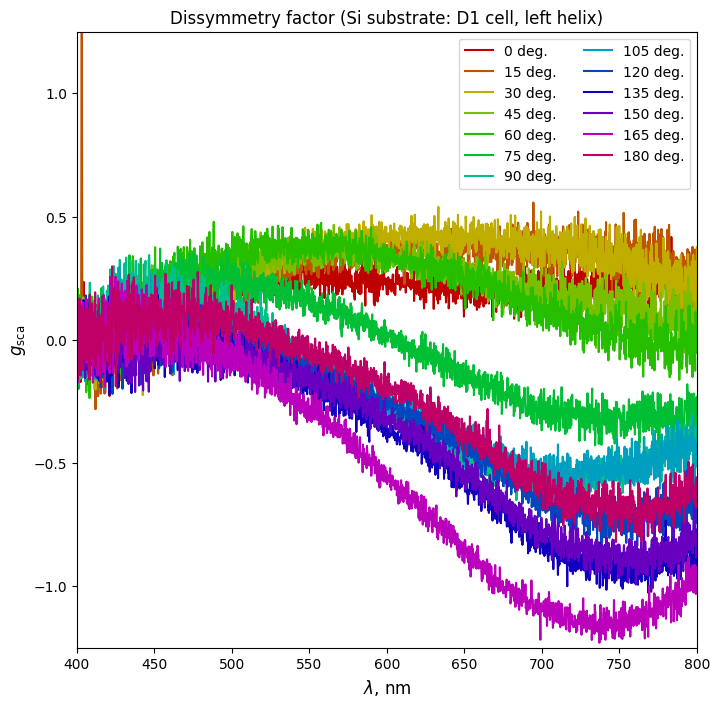

In [ ]:
r_ID = {15*i: str(34+8*i) for i in range(13)}
l_ID = {15*i: str(38+8*i) for i in range(13)}

discr_colors = cm.hsv(np.delete(np.linspace(0, 1, len(list(r_ID.keys()))+1), -1))

plt.figure(figsize=(8,8))

g_limits = np.empty_like(list(r_ID.keys()))

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(r_ID.values())[i]+'.spc')
  # print(s1.index.values)
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(l_ID.values())[i]+'.spc')
  g = dissymmetry_factor(s1, s2, lamp1, lamp2)
  g_limits[i] = max(np.abs(np.array(g)))
  plt.plot(g, color=adjust_lightness(discr_colors[i], 0.75), label='{}'.format(list(r_ID.keys())[i])+' deg.')
  plt.xlim(400, 800)

plt.ylim(-1.25*max(g_limits), 1.25*max(g_limits))
plt.xlabel(r'$\lambda$, nm', size=12)
plt.ylabel(r'$g_\text{sca}$', size=12)
plt.title(f'Dissymmetry factor (Si substrate: D1 cell, left helix)')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set3.colors)
plt.legend(ncol=2)
plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/dissym_factor_2025_04_21_D1l.png', dpi=300)

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


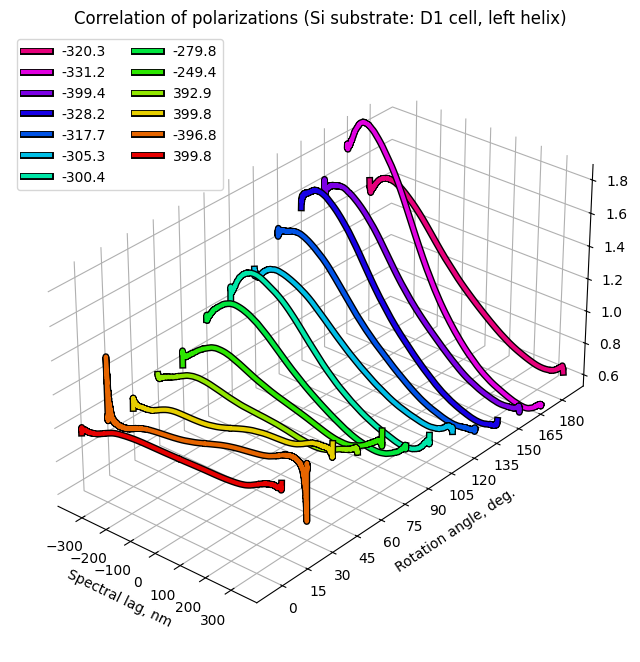

In [ ]:
fig = plt.figure(figsize=(8,9))

r_ID = {15*i: str(34+8*i) for i in range(13)}
l_ID = {15*i: str(38+8*i) for i in range(13)}

corr_limits = np.empty_like(list(r_ID.keys()))
g_limits = np.empty_like(list(r_ID.keys()))

ax = fig.add_subplot(projection='3d')
x_scaling = 2.0
y_scaling = 4.0
z_scaling = 2.0
ax.set_box_aspect([x_scaling, y_scaling, z_scaling])

shifts = []

def format_scientific(x, pos):
    return "${:.1e}$".format(x)

sci_format = mticker.FuncFormatter(format_scientific)

bottom_z_shifts = []
top_z_shifts = []

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  bottom_z_shifts = np.append(bottom_z_shifts, min(corr_g))
  top_z_shifts = np.append(top_z_shifts, max(corr_g))

bottom_z_lim = min(bottom_z_shifts)
top_z_lim = max(top_z_shifts)

for i in range(len(list(r_ID.keys()))-1, -1, -1):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  carrier_amplitude = s1.index.values[-1] - s1.index.values[0]
  corr_carrier = np.array([k for k in np.linspace(-carrier_amplitude, carrier_amplitude, len(corr_g))])
  extrema_g = find_peaks(corr_g)[0]
  corr_limits[i] = max(np.abs(np.array(corr_g)))
  shift = corr_carrier[np.argmax(corr_g)]
  ax.plot(corr_carrier, int(list(r_ID.keys())[i]), corr_g, color=adjust_lightness(discr_colors[i], 0.9), label='{}'.format(np.round(shift, decimals=1)), linewidth=3.0, path_effects=[pe.Stroke(linewidth=5.0, foreground='black'), pe.Normal()])
  shifts = np.append(shifts, shift)

ax.set_xlabel(f'Spectral lag, nm', labelpad=2)
ax.set_ylabel(f'Rotation angle, deg.', labelpad=10)
ax.legend(ncol=2, loc='upper left', fontsize=10)
ax.set_yticks(list(r_ID.keys()))
ax.set_xlim(corr_carrier[0], corr_carrier[-1])
ax.set_ylim(-15, 195)
ax.set_zlim(bottom_z_lim, top_z_lim)
plt.title(f'Correlation of polarizations (Si substrate: D1 cell, left helix)')

ax.zaxis.set_pane_color((1, 1, 1, 0))
ax.yaxis.set_pane_color((1, 1, 1, 0))
ax.xaxis.set_pane_color((1, 1, 1, 0))

ax.view_init(30, -50, 0)

plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/correlation_2025_04_21_D1l.png', dpi=300)

Semistable

B-1

Right helix

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


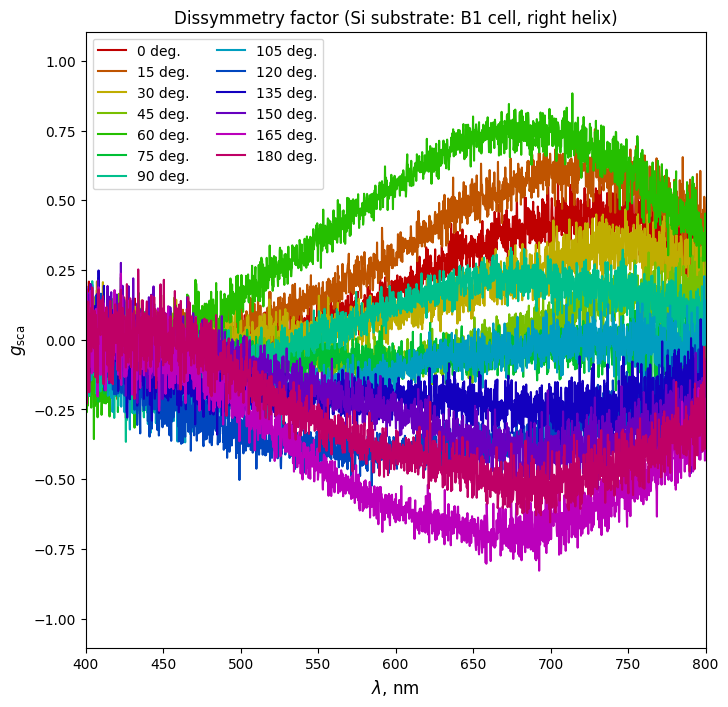

In [ ]:
r_ID = {15*i: str(33+8*i) for i in range(13)}
l_ID = {15*i: str(37+8*i) for i in range(13)}

discr_colors = cm.hsv(np.delete(np.linspace(0, 1, len(list(r_ID.keys()))+1), -1))

plt.figure(figsize=(8,8))

g_limits = np.array([])

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(l_ID.values())[i]+'.spc')
  g = dissymmetry_factor(s1, s2, lamp1, lamp2)
  g_limits = np.append(g_limits, np.max(np.abs(g)))
  plt.plot(g, color=adjust_lightness(discr_colors[i], 0.75), label='{}'.format(list(r_ID.keys())[i])+' deg.')
  plt.xlim(400, 800)

plt.ylim(-1.25*np.max(g_limits), 1.25*np.max(g_limits))
plt.xlabel(r'$\lambda$, nm', size=12)
plt.ylabel(r'$g_\text{sca}$', size=12)
plt.title(f'Dissymmetry factor (Si substrate: B1 cell, right helix)')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set3.colors)
plt.legend(ncol=2)
plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/dissym_factor_2025_04_21_B1r.png', dpi=300)

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


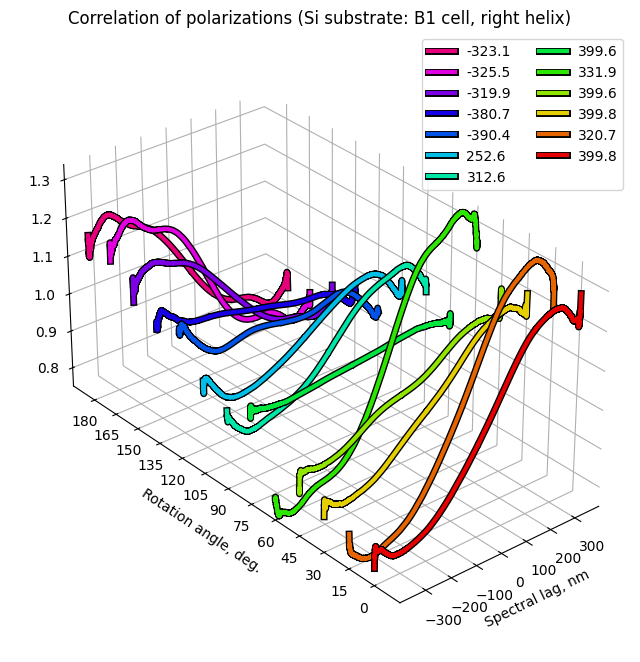

In [ ]:
fig = plt.figure(figsize=(8,9))

r_ID = {15*i: str(33+8*i) for i in range(13)}
l_ID = {15*i: str(37+8*i) for i in range(13)}

corr_limits = np.empty_like(list(r_ID.keys()))
g_limits = np.empty_like(list(r_ID.keys()))

ax = fig.add_subplot(projection='3d')
x_scaling = 2.0
y_scaling = 4.0
z_scaling = 2.0
ax.set_box_aspect([x_scaling, y_scaling, z_scaling])

shifts = []

def format_scientific(x, pos):
    return "${:.1e}$".format(x)

sci_format = mticker.FuncFormatter(format_scientific)

bottom_z_shifts = []
top_z_shifts = []

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  bottom_z_shifts = np.append(bottom_z_shifts, min(corr_g))
  top_z_shifts = np.append(top_z_shifts, max(corr_g))

bottom_z_lim = min(bottom_z_shifts)
top_z_lim = max(top_z_shifts)

for i in range(len(list(r_ID.keys()))-1, -1, -1):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  carrier_amplitude = s1.index.values[-1] - s1.index.values[0]
  corr_carrier = np.array([k for k in np.linspace(-carrier_amplitude, carrier_amplitude, len(corr_g))])
  extrema_g = find_peaks(corr_g)[0]
  corr_limits[i] = max(np.abs(np.array(corr_g)))
  shift = corr_carrier[np.argmax(corr_g)]
  ax.plot(corr_carrier, int(list(r_ID.keys())[i]), corr_g, color=adjust_lightness(discr_colors[i], 0.9), label='{}'.format(np.round(shift, decimals=1)), linewidth=3.0, path_effects=[pe.Stroke(linewidth=5.0, foreground='black'), pe.Normal()])
  shifts = np.append(shifts, shift)

ax.set_xlabel(f'Spectral lag, nm', labelpad=2)
ax.set_ylabel(f'Rotation angle, deg.', labelpad=10)
ax.legend(ncol=2, loc='upper right', fontsize=10)
ax.set_yticks(list(r_ID.keys()))
ax.set_xlim(corr_carrier[0], corr_carrier[-1])
ax.set_ylim(-15, 195)
ax.set_zlim(bottom_z_lim, top_z_lim)
plt.title(f'Correlation of polarizations (Si substrate: B1 cell, right helix)')

ax.zaxis.set_pane_color((1, 1, 1, 0))
ax.yaxis.set_pane_color((1, 1, 1, 0))
ax.xaxis.set_pane_color((1, 1, 1, 0))

ax.view_init(30, -130, 0)

plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/correlation_2025_04_21_B1r.png', dpi=300)

Left helix

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


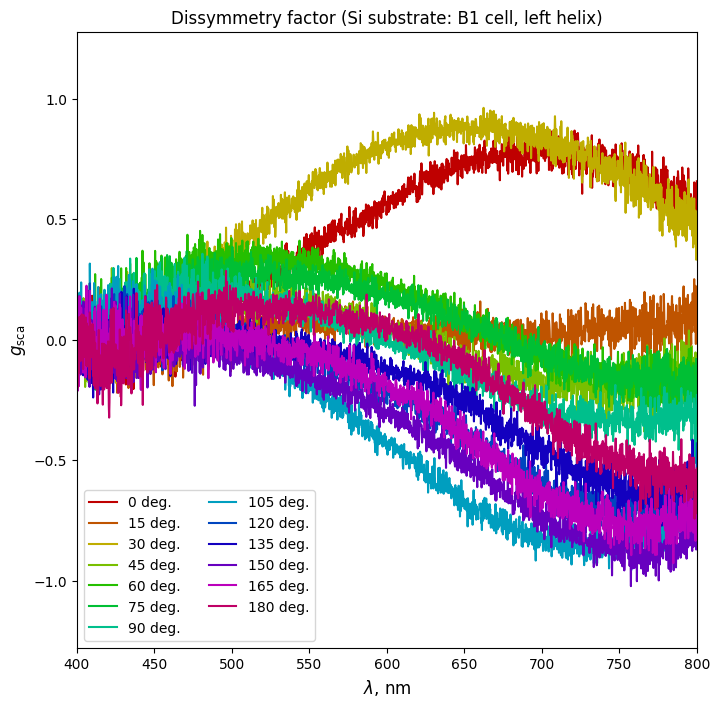

In [ ]:
r_ID = {15*i: str(35+8*i) for i in range(13)}
l_ID = {15*i: str(39+8*i) for i in range(13)}

discr_colors = cm.hsv(np.delete(np.linspace(0, 1, len(list(r_ID.keys()))+1), -1))

plt.figure(figsize=(8,8))

g_limits = np.array([])

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(l_ID.values())[i]+'.spc')
  g = dissymmetry_factor(s1, s2, lamp1, lamp2)
  g_limits = np.append(g_limits, np.max(np.abs(g)))
  plt.plot(g, color=adjust_lightness(discr_colors[i], 0.75), label='{}'.format(list(r_ID.keys())[i])+' deg.')
  plt.xlim(400, 800)

plt.ylim(-1.25*np.max(g_limits), 1.25*np.max(g_limits))
plt.xlabel(r'$\lambda$, nm', size=12)
plt.ylabel(r'$g_\text{sca}$', size=12)
plt.title(f'Dissymmetry factor (Si substrate: B1 cell, left helix)')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set3.colors)
plt.legend(ncol=2)
plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/dissym_factor_2025_04_21_B1l.png', dpi=300)

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


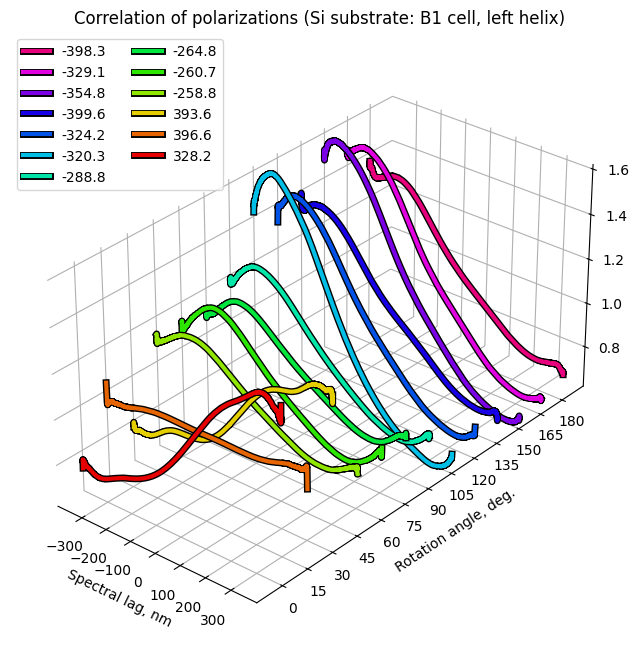

In [ ]:
fig = plt.figure(figsize=(8,9))

r_ID = {15*i: str(35+8*i) for i in range(13)}
l_ID = {15*i: str(39+8*i) for i in range(13)}

corr_limits = np.empty_like(list(r_ID.keys()))
g_limits = np.empty_like(list(r_ID.keys()))

ax = fig.add_subplot(projection='3d')
x_scaling = 2.0
y_scaling = 4.0
z_scaling = 2.0
ax.set_box_aspect([x_scaling, y_scaling, z_scaling])

shifts = []

def format_scientific(x, pos):
    return "${:.1e}$".format(x)

sci_format = mticker.FuncFormatter(format_scientific)

bottom_z_shifts = []
top_z_shifts = []

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  bottom_z_shifts = np.append(bottom_z_shifts, min(corr_g))
  top_z_shifts = np.append(top_z_shifts, max(corr_g))

bottom_z_lim = min(bottom_z_shifts)
top_z_lim = max(top_z_shifts)

for i in range(len(list(r_ID.keys()))-1, -1, -1):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_21_Zmaga/Spectrum_(LS6)-2025_04_21-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  carrier_amplitude = s1.index.values[-1] - s1.index.values[0]
  corr_carrier = np.array([k for k in np.linspace(-carrier_amplitude, carrier_amplitude, len(corr_g))])
  extrema_g = find_peaks(corr_g)[0]
  corr_limits[i] = max(np.abs(np.array(corr_g)))
  shift = corr_carrier[np.argmax(corr_g)]
  ax.plot(corr_carrier, int(list(r_ID.keys())[i]), corr_g, color=adjust_lightness(discr_colors[i], 0.9), label='{}'.format(np.round(shift, decimals=1)), linewidth=3.0, path_effects=[pe.Stroke(linewidth=5.0, foreground='black'), pe.Normal()])
  shifts = np.append(shifts, shift)

ax.set_xlabel(f'Spectral lag, nm', labelpad=2)
ax.set_ylabel(f'Rotation angle, deg.', labelpad=10)
ax.legend(ncol=2, loc='upper left', fontsize=10)
ax.set_yticks(list(r_ID.keys()))
ax.set_xlim(corr_carrier[0], corr_carrier[-1])
ax.set_ylim(-15, 195)
ax.set_zlim(bottom_z_lim, top_z_lim)
plt.title(f'Correlation of polarizations (Si substrate: B1 cell, left helix)')

ax.zaxis.set_pane_color((1, 1, 1, 0))
ax.yaxis.set_pane_color((1, 1, 1, 0))
ax.xaxis.set_pane_color((1, 1, 1, 0))

ax.view_init(30, -50, 0)

plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/correlation_2025_04_21_B1l.png', dpi=300)

$$N = 1$$

Stable

C-2

Right helix

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


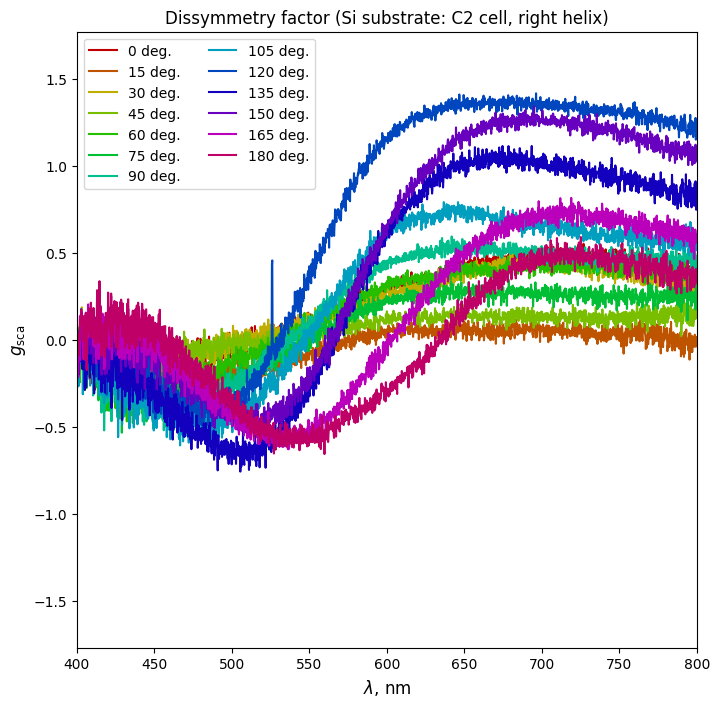

In [ ]:
lamp1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_188.spc')
lamp2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_189.spc')

r_ID = {15*i: str(136+4*i) for i in range(13)}
l_ID = {15*i: str(138+4*i) for i in range(13)}

discr_colors = cm.hsv(np.delete(np.linspace(0, 1, len(list(r_ID.keys()))+1), -1))

plt.figure(figsize=(8,8))

g_limits = np.array([])

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_'+list(l_ID.values())[i]+'.spc')
  g = dissymmetry_factor(s1, s2, lamp1, lamp2)
  g_limits = np.append(g_limits, np.max(np.abs(g)))
  plt.plot(g, color=adjust_lightness(discr_colors[i], 0.75), label='{}'.format(list(r_ID.keys())[i])+' deg.')
  plt.xlim(400, 800)

plt.ylim(-1.25*np.max(g_limits), 1.25*np.max(g_limits))
plt.xlabel(r'$\lambda$, nm', size=12)
plt.ylabel(r'$g_\text{sca}$', size=12)
plt.title(f'Dissymmetry factor (Si substrate: C2 cell, right helix)')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set3.colors)
plt.legend(ncol=2)
plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/dissym_factor_2025_04_22_C2r.png', dpi=300)

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


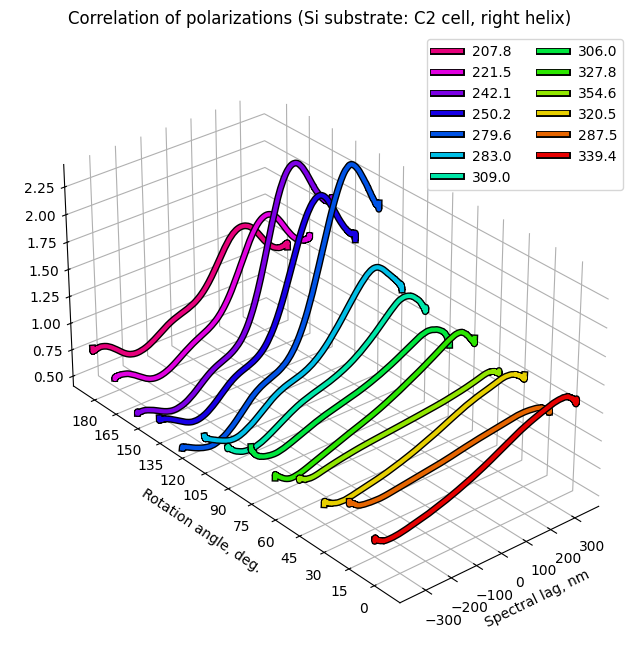

In [ ]:
fig = plt.figure(figsize=(8,9))

r_ID = {15*i: str(136+4*i) for i in range(13)}
l_ID = {15*i: str(138+4*i) for i in range(13)}

corr_limits = np.empty_like(list(r_ID.keys()))
g_limits = np.empty_like(list(r_ID.keys()))

ax = fig.add_subplot(projection='3d')
x_scaling = 2.0
y_scaling = 4.0
z_scaling = 2.0
ax.set_box_aspect([x_scaling, y_scaling, z_scaling])

shifts = []

def format_scientific(x, pos):
    return "${:.1e}$".format(x)

sci_format = mticker.FuncFormatter(format_scientific)

bottom_z_shifts = []
top_z_shifts = []

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  bottom_z_shifts = np.append(bottom_z_shifts, min(corr_g))
  top_z_shifts = np.append(top_z_shifts, max(corr_g))

bottom_z_lim = min(bottom_z_shifts)
top_z_lim = max(top_z_shifts)

for i in range(len(list(r_ID.keys()))-1, -1, -1):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  carrier_amplitude = s1.index.values[-1] - s1.index.values[0]
  corr_carrier = np.array([k for k in np.linspace(-carrier_amplitude, carrier_amplitude, len(corr_g))])
  extrema_g = find_peaks(corr_g)[0]
  corr_limits[i] = max(np.abs(np.array(corr_g)))
  shift = corr_carrier[np.argmax(corr_g)]
  ax.plot(corr_carrier, int(list(r_ID.keys())[i]), corr_g, color=adjust_lightness(discr_colors[i], 0.9), label='{}'.format(np.round(shift, decimals=1)), linewidth=3.0, path_effects=[pe.Stroke(linewidth=5.0, foreground='black'), pe.Normal()])
  shifts = np.append(shifts, shift)

ax.set_xlabel(f'Spectral lag, nm', labelpad=2)
ax.set_ylabel(f'Rotation angle, deg.', labelpad=10)
ax.legend(ncol=2, loc='upper right', fontsize=10)
ax.set_yticks(list(r_ID.keys()))
ax.set_xlim(corr_carrier[0], corr_carrier[-1])
ax.set_ylim(-15, 195)
ax.set_zlim(bottom_z_lim, top_z_lim)
plt.title(f'Correlation of polarizations (Si substrate: C2 cell, right helix)')

ax.zaxis.set_pane_color((1, 1, 1, 0))
ax.yaxis.set_pane_color((1, 1, 1, 0))
ax.xaxis.set_pane_color((1, 1, 1, 0))

ax.view_init(30, -130, 0)

plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/correlation_2025_04_21_C2r.png', dpi=300)

Left helix

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


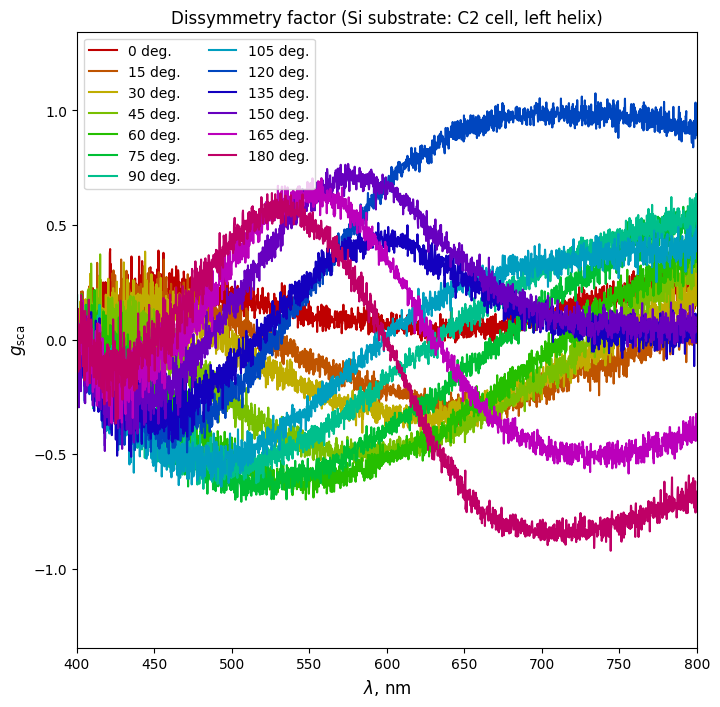

In [ ]:
r_ID = {15*i: str(137+4*i) for i in range(13)}
l_ID = {15*i: str(139+4*i) for i in range(13)}

discr_colors = cm.hsv(np.delete(np.linspace(0, 1, len(list(r_ID.keys()))+1), -1))

plt.figure(figsize=(8,8))

g_limits = np.array([])

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_'+list(l_ID.values())[i]+'.spc')
  g = dissymmetry_factor(s1, s2, lamp1, lamp2)
  g_limits = np.append(g_limits, np.max(np.abs(g)))
  plt.plot(g, color=adjust_lightness(discr_colors[i], 0.75), label='{}'.format(list(r_ID.keys())[i])+' deg.')
  plt.xlim(400, 800)

plt.ylim(-1.25*np.max(g_limits), 1.25*np.max(g_limits))
plt.xlabel(r'$\lambda$, nm', size=12)
plt.ylabel(r'$g_\text{sca}$', size=12)
plt.title(f'Dissymmetry factor (Si substrate: C2 cell, left helix)')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set3.colors)
plt.legend(ncol=2)
plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/dissym_factor_2025_04_22_C2l.png', dpi=300)

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


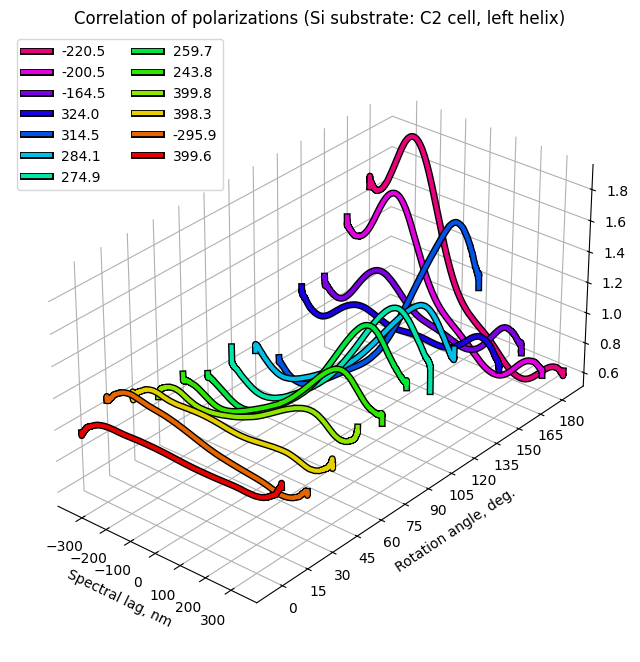

In [ ]:
fig = plt.figure(figsize=(8,9))

r_ID = {15*i: str(137+4*i) for i in range(13)}
l_ID = {15*i: str(139+4*i) for i in range(13)}

corr_limits = np.empty_like(list(r_ID.keys()))
g_limits = np.empty_like(list(r_ID.keys()))

ax = fig.add_subplot(projection='3d')
x_scaling = 2.0
y_scaling = 4.0
z_scaling = 2.0
ax.set_box_aspect([x_scaling, y_scaling, z_scaling])

shifts = []

def format_scientific(x, pos):
    return "${:.1e}$".format(x)

sci_format = mticker.FuncFormatter(format_scientific)

bottom_z_shifts = []
top_z_shifts = []

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  bottom_z_shifts = np.append(bottom_z_shifts, min(corr_g))
  top_z_shifts = np.append(top_z_shifts, max(corr_g))

bottom_z_lim = min(bottom_z_shifts)
top_z_lim = max(top_z_shifts)

for i in range(len(list(r_ID.keys()))-1, -1, -1):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_04_22_Zmaga/Spectrum_(LS6)-2025_04_22-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  carrier_amplitude = s1.index.values[-1] - s1.index.values[0]
  corr_carrier = np.array([k for k in np.linspace(-carrier_amplitude, carrier_amplitude, len(corr_g))])
  extrema_g = find_peaks(corr_g)[0]
  corr_limits[i] = max(np.abs(np.array(corr_g)))
  shift = corr_carrier[np.argmax(corr_g)]
  ax.plot(corr_carrier, int(list(r_ID.keys())[i]), corr_g, color=adjust_lightness(discr_colors[i], 0.9), label='{}'.format(np.round(shift, decimals=1)), linewidth=3.0, path_effects=[pe.Stroke(linewidth=5.0, foreground='black'), pe.Normal()])
  shifts = np.append(shifts, shift)

ax.set_xlabel(f'Spectral lag, nm', labelpad=2)
ax.set_ylabel(f'Rotation angle, deg.', labelpad=10)
ax.legend(ncol=2, loc='upper left', fontsize=10)
ax.set_yticks(list(r_ID.keys()))
ax.set_xlim(corr_carrier[0], corr_carrier[-1])
ax.set_ylim(-15, 195)
ax.set_zlim(bottom_z_lim, top_z_lim)
plt.title(f'Correlation of polarizations (Si substrate: C2 cell, left helix)')

ax.zaxis.set_pane_color((1, 1, 1, 0))
ax.yaxis.set_pane_color((1, 1, 1, 0))
ax.xaxis.set_pane_color((1, 1, 1, 0))

ax.view_init(30, -50, 0)

plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/correlation_2025_04_21_C2l.png', dpi=300)

Poorly stable

B-2

Right helix

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


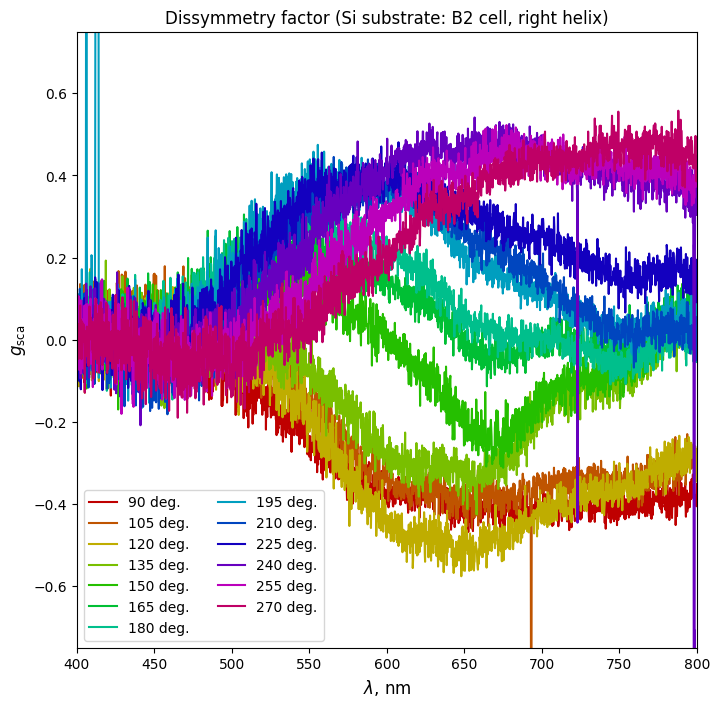

In [ ]:
lamp1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_18_Zmaga/Spectrum_(LS6)-2024_12_18-ID_65.spc')
lamp2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_18_Zmaga/Spectrum_(LS6)-2024_12_18-ID_66.spc')

r_ID = {90: '09', 105: '11', 120: '13', 135: '15', 150: '17', 165: '19',
        180: '21', 195: '23', 210: '25', 225: '33', 240: '27', 255: '29',
        270: '31'}
l_ID = {90: '10', 105: '12', 120: '14', 135: '16', 150: '18', 165: '20',
        180: '22', 195: '24', 210: '26', 225: '34', 240: '28', 255: '30',
        270: '32'}

discr_colors = cm.hsv(np.delete(np.linspace(0, 1, len(list(r_ID.keys()))+1), -1))

plt.figure(figsize=(8,8))

g_limits = np.array([])

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_18_Zmaga/Spectrum_(LS6)-2024_12_18-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_18_Zmaga/Spectrum_(LS6)-2024_12_18-ID_'+list(l_ID.values())[i]+'.spc')
  g = dissymmetry_factor(s1, s2, lamp1, lamp2)
  g_limits = np.append(g_limits, np.max(np.abs(g)))
  plt.plot(g, color=adjust_lightness(discr_colors[i], 0.75), label='{}'.format(list(r_ID.keys())[i])+' deg.')
  plt.xlim(400, 800)

plt.ylim(-0.75, 0.75)
plt.xlabel(r'$\lambda$, nm', size=12)
plt.ylabel(r'$g_\text{sca}$', size=12)
plt.title(f'Dissymmetry factor (Si substrate: B2 cell, right helix)')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set3.colors)
plt.legend(ncol=2)
plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/dissym_factor_2024_12_18_B2r.png', dpi=300)

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


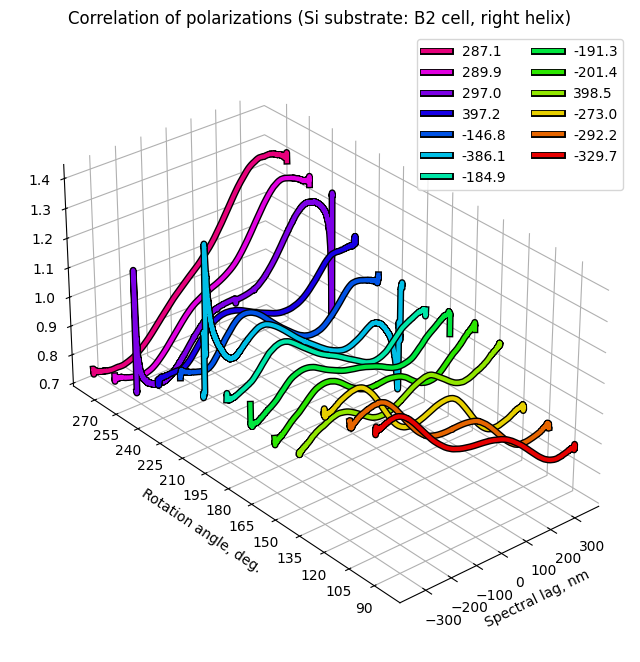

In [ ]:
fig = plt.figure(figsize=(8,9))

r_ID = {90: '09', 105: '11', 120: '13', 135: '15', 150: '17', 165: '19',
        180: '21', 195: '23', 210: '25', 225: '33', 240: '27', 255: '29',
        270: '31'}
l_ID = {90: '10', 105: '12', 120: '14', 135: '16', 150: '18', 165: '20',
        180: '22', 195: '24', 210: '26', 225: '34', 240: '28', 255: '30',
        270: '32'}

corr_limits = np.empty_like(list(r_ID.keys()))
g_limits = np.empty_like(list(r_ID.keys()))

ax = fig.add_subplot(projection='3d')
x_scaling = 2.0
y_scaling = 4.0
z_scaling = 2.0
ax.set_box_aspect([x_scaling, y_scaling, z_scaling])

shifts = []

def format_scientific(x, pos):
    return "${:.1e}$".format(x)

sci_format = mticker.FuncFormatter(format_scientific)

bottom_z_shifts = []
top_z_shifts = []

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_18_Zmaga/Spectrum_(LS6)-2024_12_18-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_18_Zmaga/Spectrum_(LS6)-2024_12_18-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  bottom_z_shifts = np.append(bottom_z_shifts, min(corr_g))
  top_z_shifts = np.append(top_z_shifts, max(corr_g))

bottom_z_lim = min(bottom_z_shifts)
top_z_lim = max(top_z_shifts)

for i in range(len(list(r_ID.keys()))-1, -1, -1):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_18_Zmaga/Spectrum_(LS6)-2024_12_18-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_18_Zmaga/Spectrum_(LS6)-2024_12_18-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  carrier_amplitude = s1.index.values[-1] - s1.index.values[0]
  corr_carrier = np.array([k for k in np.linspace(-carrier_amplitude, carrier_amplitude, len(corr_g))])
  extrema_g = find_peaks(corr_g)[0]
  corr_limits[i] = max(np.abs(np.array(corr_g)))
  shift = corr_carrier[np.argmax(corr_g)]
  ax.plot(corr_carrier, int(list(r_ID.keys())[i]), corr_g, color=adjust_lightness(discr_colors[i], 0.9), label='{}'.format(np.round(shift, decimals=1)), linewidth=3.0, path_effects=[pe.Stroke(linewidth=5.0, foreground='black'), pe.Normal()])
  shifts = np.append(shifts, shift)

ax.set_xlabel(f'Spectral lag, nm', labelpad=2)
ax.set_ylabel(f'Rotation angle, deg.', labelpad=10)
ax.legend(ncol=2, loc='upper right', fontsize=10)
ax.set_yticks(list(r_ID.keys()))
ax.set_xlim(corr_carrier[0], corr_carrier[-1])
ax.set_ylim(75, 285)
ax.set_zlim(bottom_z_lim, top_z_lim)
plt.title(f'Correlation of polarizations (Si substrate: B2 cell, right helix)')

ax.zaxis.set_pane_color((1, 1, 1, 0))
ax.yaxis.set_pane_color((1, 1, 1, 0))
ax.xaxis.set_pane_color((1, 1, 1, 0))

ax.view_init(30, -130, 0)

plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/correlation_2024_12_18_B2r.png', dpi=300)

Left helix

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


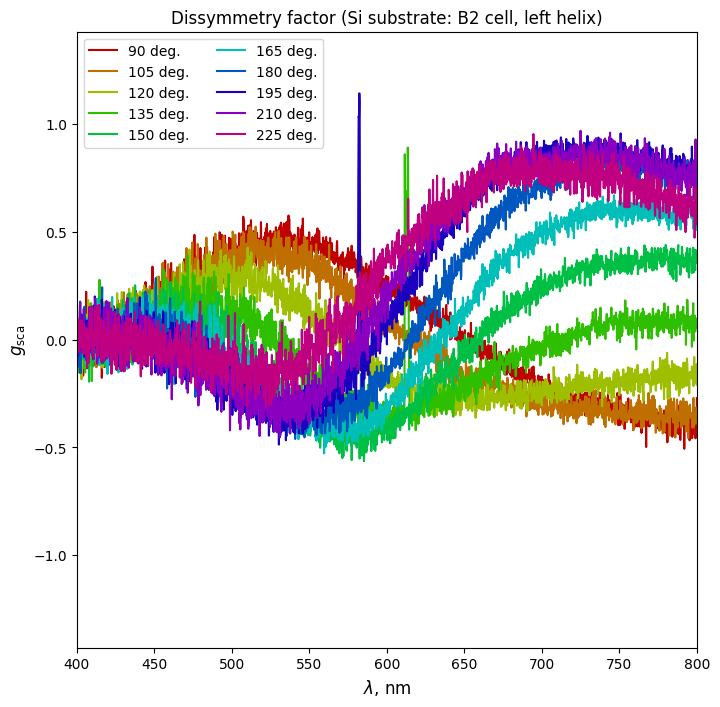

In [ ]:
lamp1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_18_Zmaga/Spectrum_(LS6)-2024_12_18-ID_65.spc')
lamp2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_18_Zmaga/Spectrum_(LS6)-2024_12_18-ID_66.spc')

r_ID = {90+15*i: str(23+2*i) for i in range(10)}
l_ID = {90+15*i: str(24+2*i) for i in range(10)}

discr_colors = cm.hsv(np.delete(np.linspace(0, 1, len(list(r_ID.keys()))+1), -1))

plt.figure(figsize=(8,8))

g_limits = np.array([])

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_11_Zmaga/Spectrum_(LS6)-2024_12_11-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_11_Zmaga/Spectrum_(LS6)-2024_12_11-ID_'+list(l_ID.values())[i]+'.spc')
  g = dissymmetry_factor(s1, s2, lamp1, lamp2)
  g_limits = np.append(g_limits, np.max(np.abs(g)))
  plt.plot(g, color=adjust_lightness(discr_colors[i], 0.75), label='{}'.format(list(r_ID.keys())[i])+' deg.')
  plt.xlim(400, 800)

plt.ylim(-1.25*np.max(g_limits), 1.25*np.max(g_limits))
plt.xlabel(r'$\lambda$, nm', size=12)
plt.ylabel(r'$g_\text{sca}$', size=12)
plt.title(f'Dissymmetry factor (Si substrate: B2 cell, left helix)')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set3.colors)
plt.legend(ncol=2)
plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/dissym_factor_2024_12_11_B2l.png', dpi=300)

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


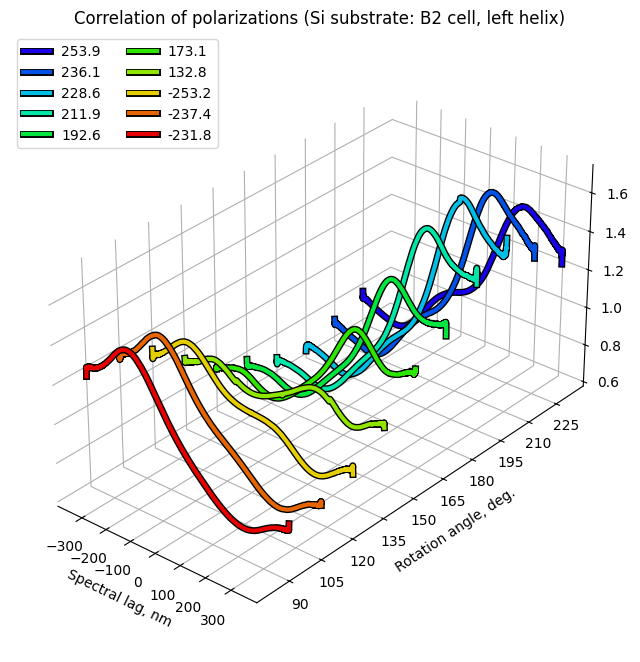

In [ ]:
fig = plt.figure(figsize=(8,9))

r_ID = {90+15*i: str(23+2*i) for i in range(10)}
l_ID = {90+15*i: str(24+2*i) for i in range(10)}

corr_limits = np.empty_like(list(r_ID.keys()))
g_limits = np.empty_like(list(r_ID.keys()))

ax = fig.add_subplot(projection='3d')
x_scaling = 2.0
y_scaling = 4.0
z_scaling = 2.0
ax.set_box_aspect([x_scaling, y_scaling, z_scaling])

shifts = []

def format_scientific(x, pos):
    return "${:.1e}$".format(x)

sci_format = mticker.FuncFormatter(format_scientific)

bottom_z_shifts = []
top_z_shifts = []

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_11_Zmaga/Spectrum_(LS6)-2024_12_11-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_11_Zmaga/Spectrum_(LS6)-2024_12_11-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  bottom_z_shifts = np.append(bottom_z_shifts, min(corr_g))
  top_z_shifts = np.append(top_z_shifts, max(corr_g))

bottom_z_lim = min(bottom_z_shifts)
top_z_lim = max(top_z_shifts)

for i in range(len(list(r_ID.keys()))-1, -1, -1):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_11_Zmaga/Spectrum_(LS6)-2024_12_11-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2024_12_11_Zmaga/Spectrum_(LS6)-2024_12_11-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  carrier_amplitude = s1.index.values[-1] - s1.index.values[0]
  corr_carrier = np.array([k for k in np.linspace(-carrier_amplitude, carrier_amplitude, len(corr_g))])
  extrema_g = find_peaks(corr_g)[0]
  corr_limits[i] = max(np.abs(np.array(corr_g)))
  shift = corr_carrier[np.argmax(corr_g)]
  ax.plot(corr_carrier, int(list(r_ID.keys())[i]), corr_g, color=adjust_lightness(discr_colors[i], 0.9), label='{}'.format(np.round(shift, decimals=1)), linewidth=3.0, path_effects=[pe.Stroke(linewidth=5.0, foreground='black'), pe.Normal()])
  shifts = np.append(shifts, shift)

ax.set_xlabel(f'Spectral lag, nm', labelpad=2)
ax.set_ylabel(f'Rotation angle, deg.', labelpad=10)
ax.legend(ncol=2, loc='upper left', fontsize=10)
ax.set_yticks(list(r_ID.keys()))
ax.set_xlim(corr_carrier[0], corr_carrier[-1])
ax.set_ylim(75, 240)
ax.set_zlim(bottom_z_lim, top_z_lim)
plt.title(f'Correlation of polarizations (Si substrate: B2 cell, left helix)')

ax.zaxis.set_pane_color((1, 1, 1, 0))
ax.yaxis.set_pane_color((1, 1, 1, 0))
ax.xaxis.set_pane_color((1, 1, 1, 0))

ax.view_init(30, -50, 0)

plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/correlation_2024_12_11_B2l.png', dpi=300)

$$N = 2$$

Stable

B-4

Right helix

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in reciprocal
  result = getattr(ufunc, method)(*inputs, **kwargs)


x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


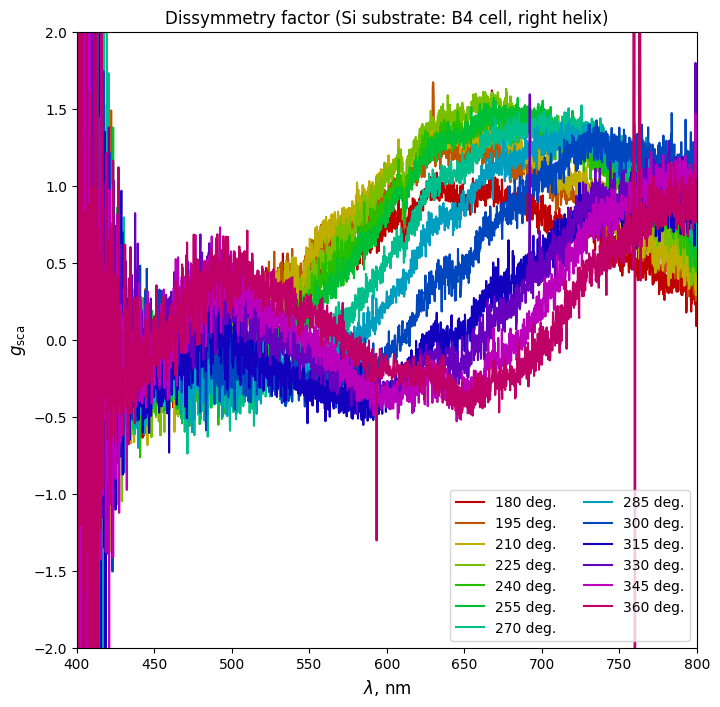

In [ ]:
lamp1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_53.spc')
lamp2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_54.spc')

r_ID_low = {180+15*i: str(0)+str(1+2*i) for i in range(5)}
r_ID_high = {180+15*i: str(1+2*i) for i in range(5,13)}
r_ID = r_ID_low.copy()
r_ID.update(r_ID_high)
l_ID_low = {180+15*i: str(0)+str(2+2*i) for i in range(4)}
l_ID_high = {180+15*i: str(2+2*i) for i in range(4,13)}
l_ID = l_ID_low.copy()
l_ID.update(l_ID_high)

discr_colors = cm.hsv(np.delete(np.linspace(0, 1, len(list(r_ID.keys()))+1), -1))

plt.figure(figsize=(8,8))

g_limits = np.array([])

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_'+list(l_ID.values())[i]+'.spc')
  g = dissymmetry_factor(s1, s2, lamp1, lamp2)
  g_limits = np.append(g_limits, np.max(np.abs(g)))
  plt.plot(g, color=adjust_lightness(discr_colors[i], 0.75), label='{}'.format(list(r_ID.keys())[i])+' deg.')
  plt.xlim(400, 800)

plt.ylim(-2, 2)
plt.xlabel(r'$\lambda$, nm', size=12)
plt.ylabel(r'$g_\text{sca}$', size=12)
plt.title(f'Dissymmetry factor (Si substrate: B4 cell, right helix)')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set3.colors)
plt.legend(ncol=2)
plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/dissym_factor_2025_02_03_B4r.png', dpi=300)

In [ ]:
import math

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


<ipython-input-6-b75f5a2b7387>:11: RuntimeWarning: invalid value encountered in sqrt
  return np.divide(np.correlate(x, y, mode='full'), np.sqrt(np.multiply(np.correlate(x, x, mode='full'), np.correlate(y, y, mode='full'))))
<ipython-input-6-b75f5a2b7387>:11: RuntimeWarning: divide by zero encountered in divide
  return np.divide(np.correlate(x, y, mode='full'), np.sqrt(np.multiply(np.correlate(x, x, mode='full'), np.correlate(y, y, mode='full'))))
<ipython-input-6-b75f5a2b7387>:11: RuntimeWarning: invalid value encountered in divide
  return np.divide(np.correlate(x, y, mode='full'), np.sqrt(np.multiply(np.correlate(x, x, mode='full'), np.correlate(y, y, mode='full'))))


x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


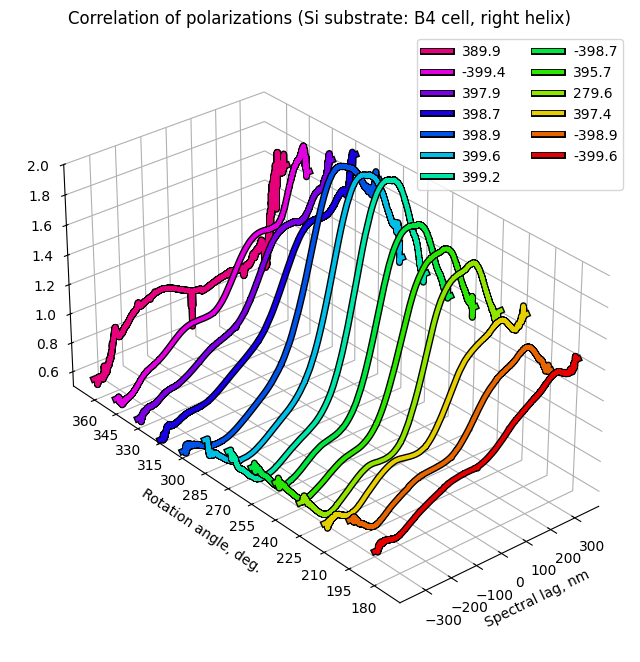

In [ ]:
fig = plt.figure(figsize=(8,9))

r_ID_low = {180+15*i: str(0)+str(1+2*i) for i in range(5)}
r_ID_high = {180+15*i: str(1+2*i) for i in range(5,13)}
r_ID = r_ID_low.copy()
r_ID.update(r_ID_high)
l_ID_low = {180+15*i: str(0)+str(2+2*i) for i in range(4)}
l_ID_high = {180+15*i: str(2+2*i) for i in range(4,13)}
l_ID = l_ID_low.copy()
l_ID.update(l_ID_high)

corr_limits = np.empty_like(list(r_ID.keys()))
g_limits = np.empty_like(list(r_ID.keys()))

ax = fig.add_subplot(projection='3d')
x_scaling = 2.0
y_scaling = 4.0
z_scaling = 2.0
ax.set_box_aspect([x_scaling, y_scaling, z_scaling])

shifts = []

def format_scientific(x, pos):
    return "${:.1e}$".format(x)

sci_format = mticker.FuncFormatter(format_scientific)

bottom_z_shifts = []
top_z_shifts = []

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  corr_g[~np.isfinite(corr_g)] = 0
  carrier_amplitude = s1.index.values[-1] - s1.index.values[0]
  corr_carrier = np.array([k for k in np.linspace(-carrier_amplitude, carrier_amplitude, len(corr_g))])
  corr_g_finite = filter_ends(corr_g, corr_carrier, 0.97*np.max(np.abs(corr_carrier)))
  bottom_z_shifts = np.append(bottom_z_shifts, min(corr_g_finite))
  top_z_shifts = np.append(top_z_shifts, min(corr_g))

bottom_z_lim = min(bottom_z_shifts)
top_z_lim = max(top_z_shifts)

for i in range(len(list(r_ID.keys()))-1, -1, -1):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  corr_g[~np.isfinite(corr_g)] = 0
  carrier_amplitude = s1.index.values[-1] - s1.index.values[0]
  corr_carrier = np.array([k for k in np.linspace(-carrier_amplitude, carrier_amplitude, len(corr_g))])
  corr_g_finite = filter_ends(corr_g, corr_carrier, 0.97*np.max(np.abs(corr_carrier)))
  extrema_g = find_peaks(corr_g)[0]
  if math.isnan(max(np.abs(np.array(corr_g)))) == False and math.isinf(max(np.abs(np.array(corr_g)))) == False:
    corr_limits[i] = max(np.abs(np.array(corr_g)))
  else:
    corr_limits[i] = 0
  shift = corr_carrier[np.argmax(corr_g)]
  ax.plot(corr_carrier, int(list(r_ID.keys())[i]), corr_g_finite, color=adjust_lightness(discr_colors[i], 0.9), label='{}'.format(np.round(shift, decimals=1)), linewidth=3.0, path_effects=[pe.Stroke(linewidth=5.0, foreground='black'), pe.Normal()])
  shifts = np.append(shifts, shift)

ax.set_xlabel(f'Spectral lag, nm', labelpad=2)
ax.set_ylabel(f'Rotation angle, deg.', labelpad=10)
ax.legend(ncol=2, loc='upper right', fontsize=10)
ax.set_yticks(list(r_ID.keys()))
ax.set_xlim(corr_carrier[0], corr_carrier[-1])
ax.set_ylim(165, 375)
ax.set_zlim(0.5, 2.0)
plt.title(f'Correlation of polarizations (Si substrate: B4 cell, right helix)')

ax.zaxis.set_pane_color((1, 1, 1, 0))
ax.yaxis.set_pane_color((1, 1, 1, 0))
ax.xaxis.set_pane_color((1, 1, 1, 0))

ax.view_init(30, -130, 0)

plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/correlation_2024_12_18_B4r.png', dpi=300)

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in reciprocal
  result = getattr(ufunc, method)(*inputs, **kwargs)


x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


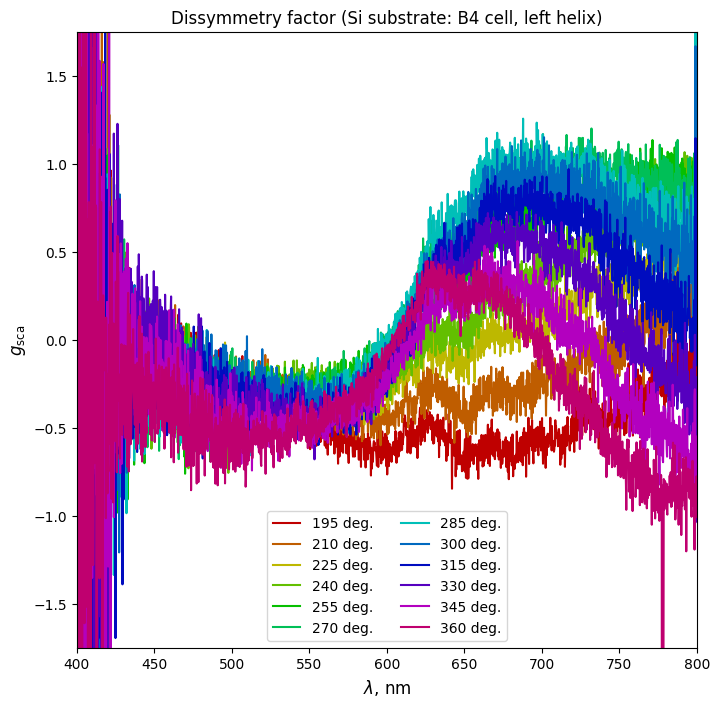

In [ ]:
r_ID = {180+15*i: str(51-2*i) for i in range(1,13)}
l_ID = {180+15*i: str(52-2*i) for i in range(1,13)}

discr_colors = cm.hsv(np.delete(np.linspace(0, 1, len(list(r_ID.keys()))+1), -1))

plt.figure(figsize=(8,8))

g_limits = np.array([])

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_'+list(l_ID.values())[i]+'.spc')
  g = dissymmetry_factor(s1, s2, lamp1, lamp2)
  g_limits = np.append(g_limits, np.max(np.abs(g)))
  plt.plot(g, color=adjust_lightness(discr_colors[i], 0.75), label='{}'.format(list(r_ID.keys())[i])+' deg.')
  plt.xlim(400, 800)

plt.ylim(-1.75, 1.75)
plt.xlabel(r'$\lambda$, nm', size=12)
plt.ylabel(r'$g_\text{sca}$', size=12)
plt.title(f'Dissymmetry factor (Si substrate: B4 cell, left helix)')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set3.colors)
plt.legend(ncol=2)
plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/dissym_factor_2025_02_03_B4l.png', dpi=300)

x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


<ipython-input-6-b75f5a2b7387>:11: RuntimeWarning: invalid value encountered in sqrt
  return np.divide(np.correlate(x, y, mode='full'), np.sqrt(np.multiply(np.correlate(x, x, mode='full'), np.correlate(y, y, mode='full'))))
<ipython-input-6-b75f5a2b7387>:11: RuntimeWarning: divide by zero encountered in divide
  return np.divide(np.correlate(x, y, mode='full'), np.sqrt(np.multiply(np.correlate(x, x, mode='full'), np.correlate(y, y, mode='full'))))
<ipython-input-6-b75f5a2b7387>:11: RuntimeWarning: invalid value encountered in divide
  return np.divide(np.correlate(x, y, mode='full'), np.sqrt(np.multiply(np.correlate(x, x, mode='full'), np.correlate(y, y, mode='full'))))


x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)
x-y(1)


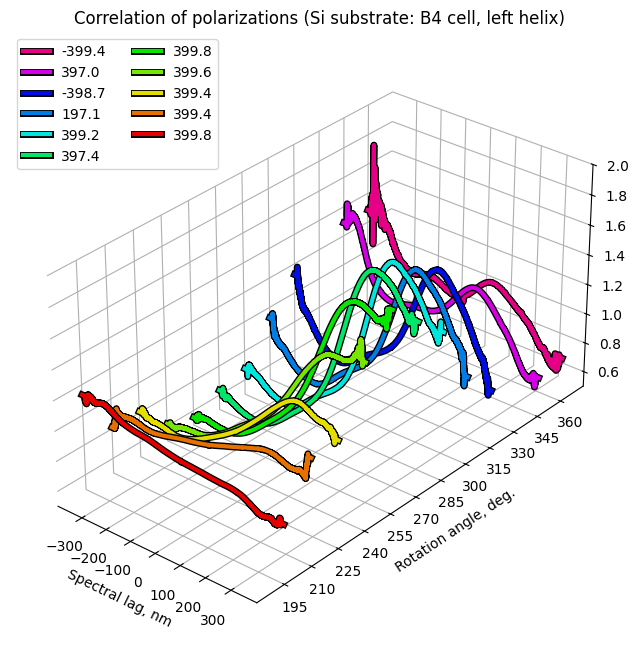

In [ ]:
fig = plt.figure(figsize=(8,9))

r_ID = {180+15*i: str(51-2*i) for i in range(1,13)}
l_ID = {180+15*i: str(52-2*i) for i in range(1,13)}

corr_limits = np.empty_like(list(r_ID.keys()))
g_limits = np.empty_like(list(r_ID.keys()))

ax = fig.add_subplot(projection='3d')
x_scaling = 2.0
y_scaling = 4.0
z_scaling = 2.0
ax.set_box_aspect([x_scaling, y_scaling, z_scaling])

shifts = []

def format_scientific(x, pos):
    return "${:.1e}$".format(x)

sci_format = mticker.FuncFormatter(format_scientific)

bottom_z_shifts = []
top_z_shifts = []

for i in range(len(list(r_ID.keys()))):
  s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_'+list(r_ID.values())[i]+'.spc')
  s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_'+list(l_ID.values())[i]+'.spc')
  corr_g = correlation_2(s1, s2)
  corr_g[~np.isfinite(corr_g)] = 0
  carrier_amplitude = s1.index.values[-1] - s1.index.values[0]
  corr_carrier = np.array([k for k in np.linspace(-carrier_amplitude, carrier_amplitude, len(corr_g))])
  corr_g_finite = filter_ends(corr_g, corr_carrier, 0.97*np.max(np.abs(corr_carrier)))
  bottom_z_shifts = np.append(bottom_z_shifts, min(corr_g_finite))
  top_z_shifts = np.append(top_z_shifts, min(corr_g))

bottom_z_lim = min(bottom_z_shifts)
top_z_lim = max(top_z_shifts)

for i in range(len(list(r_ID.keys()))-1, -1, -1):
  if i != 9:
    s1 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_'+list(r_ID.values())[i]+'.spc')
    s2 = read_spc('/content/drive/MyDrive/Circular_dichroism/2025_02_03_Zmaga/Spectrum_(LS6)-2025_02_03-ID_'+list(l_ID.values())[i]+'.spc')
    corr_g = correlation_2(s1, s2)
    corr_g[~np.isfinite(corr_g)] = 0
    carrier_amplitude = s1.index.values[-1] - s1.index.values[0]
    corr_carrier = np.array([k for k in np.linspace(-carrier_amplitude, carrier_amplitude, len(corr_g))])
    corr_g_finite = filter_ends(corr_g, corr_carrier, 0.97*np.max(np.abs(corr_carrier)))
    extrema_g = find_peaks(corr_g)[0]
    if math.isnan(max(np.abs(np.array(corr_g)))) == False and math.isinf(max(np.abs(np.array(corr_g)))) == False:
      corr_limits[i] = max(np.abs(np.array(corr_g)))
    else:
      corr_limits[i] = 0
    shift = corr_carrier[np.argmax(corr_g)]
    ax.plot(corr_carrier, int(list(r_ID.keys())[i]), corr_g_finite, color=adjust_lightness(discr_colors[i], 0.9), label='{}'.format(np.round(shift, decimals=1)), linewidth=3.0, path_effects=[pe.Stroke(linewidth=5.0, foreground='black'), pe.Normal()])
    shifts = np.append(shifts, shift)

ax.set_xlabel(f'Spectral lag, nm', labelpad=2)
ax.set_ylabel(f'Rotation angle, deg.', labelpad=10)
ax.legend(ncol=2, loc='upper left', fontsize=10)
ax.set_yticks(list(r_ID.keys()))
ax.set_xlim(corr_carrier[0], corr_carrier[-1])
ax.set_ylim(180, 375)
ax.set_zlim(0.5, 2.0)
plt.title(f'Correlation of polarizations (Si substrate: B4 cell, left helix)')

ax.zaxis.set_pane_color((1, 1, 1, 0))
ax.yaxis.set_pane_color((1, 1, 1, 0))
ax.xaxis.set_pane_color((1, 1, 1, 0))

ax.view_init(30, -50, 0)

plt.savefig('/content/drive/MyDrive/Circular_dichroism/Final_results/correlation_2024_12_18_B4l.png', dpi=300)